# BÀI TẬP: EDA HOÀN CHỈNH — TITANIC
## Data Profiling → Descriptive Statistics → Define the Question
**Nguồn:** kaggle.com/c/titanic (891 dòng)

```
PHẦN A — DATA PROFILING       : dữ liệu sạch chưa, có gì
PHẦN B — DESCRIPTIVE STATS    : từng biến trông như thế nào
PHẦN C — DEFINE THE QUESTION  : đặt câu hỏi kinh doanh, trả lời bằng code, rút insight
```

## Setup

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [2]:
# TODO
print("số dòng:", df.shape[0], "| số cột:", df.shape[1])
print()
df.info()

số dòng: 891 | số cột: 15

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


## A.2. Missing values & Duplicate data

In [7]:
# TODO
missing = df.isnull().sum()
print("missing values:")
print(missing[missing>0] if missing.sum()>0 else "không có cột nào thiếu dữ liệu")
print()
print("duplicate row:", df.duplicated().sum())

missing values:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

duplicate row: 107


## A.3. Invalid values

In [11]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [17]:
# TODO
print("sibsp < 0:", (df['sibsp']<0).sum())
print("fare < 0:", (df['fare']<0).sum())
print("survived ngoài [0,1]:", ((df['survived']<0)|(df['survived']>1)).sum())
print("age <= 0:", (df['age']<=0).sum())
print("pclass ngoài [1,2,3]", ((df['pclass']<1)|(df['pclass']>3)).sum())
print("parch < 0:", (df['parch']<0).sum())
print()
print("=> Đã kiểm tra các giá trị vô lý theo quy tắc của từng biến")

sibsp < 0: 0
fare < 0: 0
survived ngoài [0,1]: 0
age <= 0: 0
pclass ngoài [1,2,3] 0
parch < 0: 0

=> Đã kiểm tra các giá trị vô lý theo quy tắc của từng biến


## A.4. Create a new column
Tạo cột `family_size` = sibsp + parch + 1.

In [20]:
# TODO
df['family_size'] = df['sibsp'] + df['parch'] + 1


In [21]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,1
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,1
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,4
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,1


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [25]:
# TODO
for col in ['age', 'fare', 'family_size']:
    mean_, median_, mode_ = df[col].mean(), df[col].median(), df[col].mode()[0]
    print(f"{col}: Mean={mean_:.2f}, Median={median_:.2f}, Mode={mode_:.2f}")
print()
print("Mode sex:", df['sex'].mode()[0])
print("Mode class:", df['class'].mode()[0])
print("Mode embark_town:", df['embark_town'].mode()[0])

age: Mean=29.70, Median=28.00, Mode=24.00
fare: Mean=32.20, Median=14.45, Mode=8.05
family_size: Mean=1.90, Median=1.00, Mode=1.00

Mode sex: male
Mode class: Third
Mode embark_town: Southampton


## Group 2 — Dispersion

In [26]:
# TODO
for col in ['age','fare', 'family_size']:
    s = df[col]
    range_ = s.max()-s.min()
    std_ = s.std()
    q1,q3 = s.quantile([0.25,0.75]); iqr = q3-q1
    cv = std_/s.mean()
    print(f"--- {col} ---")
    print(f"Range={range_:.2f}, Std={std_:.2f}, IQR={iqr:.2f}, CV={cv:.2f}")

--- age ---
Range=79.58, Std=14.53, IQR=17.88, CV=0.49
--- fare ---
Range=512.33, Std=49.69, IQR=23.09, CV=1.54
--- family_size ---
Range=10.00, Std=1.61, IQR=1.00, CV=0.85


## Group 3 — Location and Shape

--- age ---
P25=20.12, P50=28.00, P75=38.00
Skewness=0.39, Kurtosis=0.17
--- fare ---
P25=7.91, P50=14.45, P75=31.00
Skewness=4.78, Kurtosis=33.20
--- family_size ---
P25=1.00, P50=1.00, P75=2.00
Skewness=2.72, Kurtosis=9.10


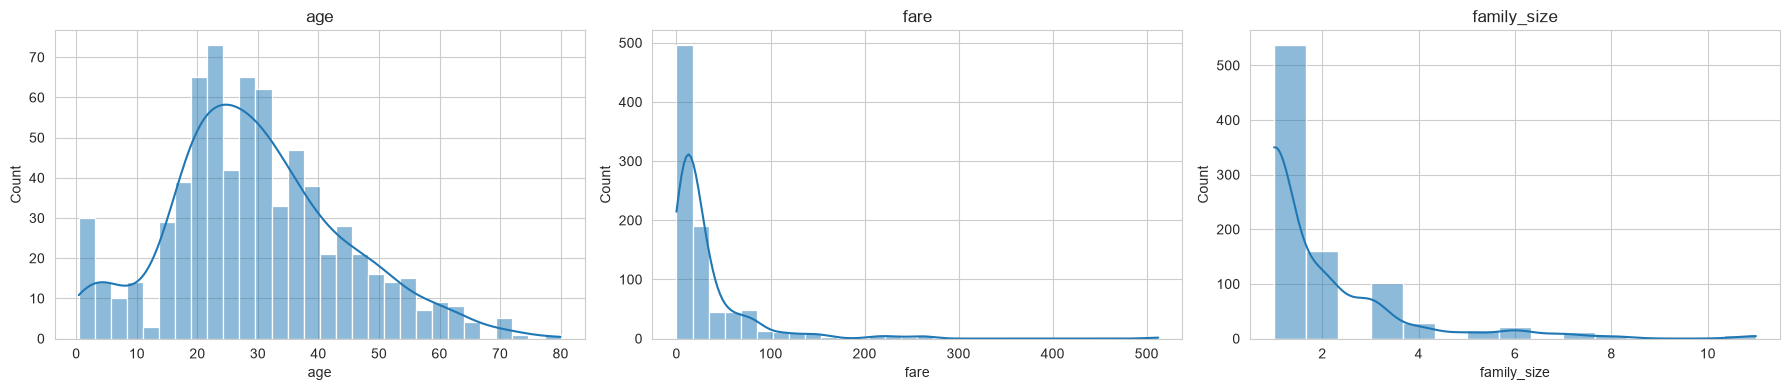

Nhận xét: fare lệch phải và có kurtosis cao hơn hẳn age và family_size -> có khả năng xuất hiện các giá trị cực đoan.


In [29]:
# TODO
for col in ['age','fare', 'family_size']:
    s = df[col]
    skew_, kurt_ = stats.skew(s.dropna()), stats.kurtosis(s.dropna())
    print(f"--- {col} ---")
    print(f"P25={s.quantile(0.25):.2f}, "
          f"P50={s.quantile(0.5):.2f}, "
          f"P75={s.quantile(0.75):.2f}")
    print(f"Skewness={skew_:.2f}, Kurtosis={kurt_:.2f}")

fig,axes = plt.subplots(1,3,figsize=(18,4))
sns.histplot(df['age'],bins=30,kde=True,ax=axes[0]); axes[0].set_title('age')
sns.histplot(df['fare'],bins=30,kde=True,ax=axes[1]); axes[1].set_title('fare')
sns.histplot(df['family_size'],bins=15,kde=True,ax=axes[2]); axes[2].set_title('family_size')
plt.tight_layout(); plt.show()

print("Nhận xét: fare lệch phải và có kurtosis cao hơn hẳn age và family_size -> có khả năng xuất hiện các giá trị cực đoan.")

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Hạng vé nào có tỷ lệ sống sót cao nhất, chênh lệch bao nhiêu so với hạng thấp nhất?

pclass
1    62.96
2    47.28
3    24.24
Name: survived, dtype: float64

=> Hạng 1 có tỷ lệ sống sót cao nhất: 63.0%.
Chênh lệch: 38.73%.


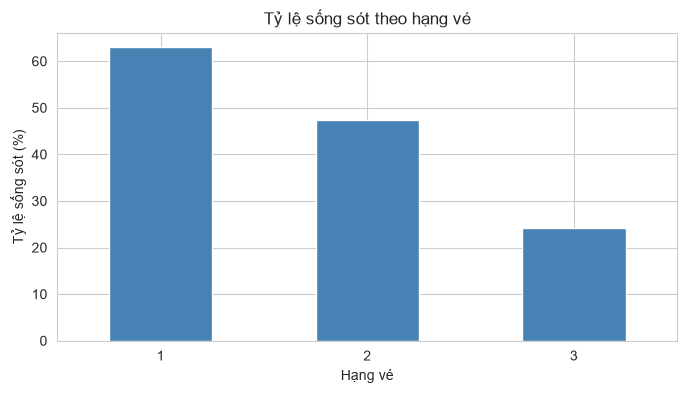

In [33]:
# TODO
survival_by_class = df.groupby('pclass')['survived'].mean().sort_values(ascending=False)
top_class = survival_by_class.index[0]
top_pct = survival_by_class.iloc[0] * 100
lowest_pct = survival_by_class.iloc[-1] * 100
difference = top_pct - lowest_pct

print((survival_by_class * 100).round(2))
print(f"\n=> Hạng {top_class} có tỷ lệ sống sót cao nhất: {top_pct:.1f}%.")
print(f"Chênh lệch: {difference:.2f}%.")

fig,ax=plt.subplots(figsize=(8,4))
(survival_by_class*100).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Tỷ lệ sống sót theo hạng vé'); ax.set_xlabel('Hạng vé'); ax.set_ylabel('Tỷ lệ sống sót (%)'); plt.xticks(rotation=0); plt.show()

## Câu hỏi 2: Giới tính hay hạng vé ảnh hưởng đến sống sót mạnh hơn?

In [34]:
# TODO
survival_by_sex = df.groupby('sex')['survived'].mean().sort_values(ascending=False)

print("Tỷ lệ sống sót theo giới tính:")
print((survival_by_sex * 100).round(2))

sex_difference = (survival_by_sex.max() - survival_by_sex.min())* 100

print(f"Chênh lệch theo giới tính: {sex_difference:.2f}%")

Tỷ lệ sống sót theo giới tính:
sex
female    74.20
male      18.89
Name: survived, dtype: float64
Chênh lệch theo giới tính: 55.31%


In [35]:
survival_by_class = df.groupby('pclass')['survived'].mean().sort_values(ascending=False)

print("Tỷ lệ sống sót theo hạng vé:")
print((survival_by_class * 100).round(2))

class_difference = (survival_by_class.max() - survival_by_class.min()) * 100

print(f"Chênh lệch theo hạng vé: {class_difference:.2f}%")


Tỷ lệ sống sót theo hạng vé:
pclass
1    62.96
2    47.28
3    24.24
Name: survived, dtype: float64
Chênh lệch theo hạng vé: 38.73%



=> Giới tính có mức chênh lệch tỷ lệ sống sót lớn hơn hạng vé.

Giới tính có mức chênh lệc tỷ lệ sống sót lớn hơn hạng vé => giới tính có mối liên hệ mạnh hơn với sống sót so với hạng vé


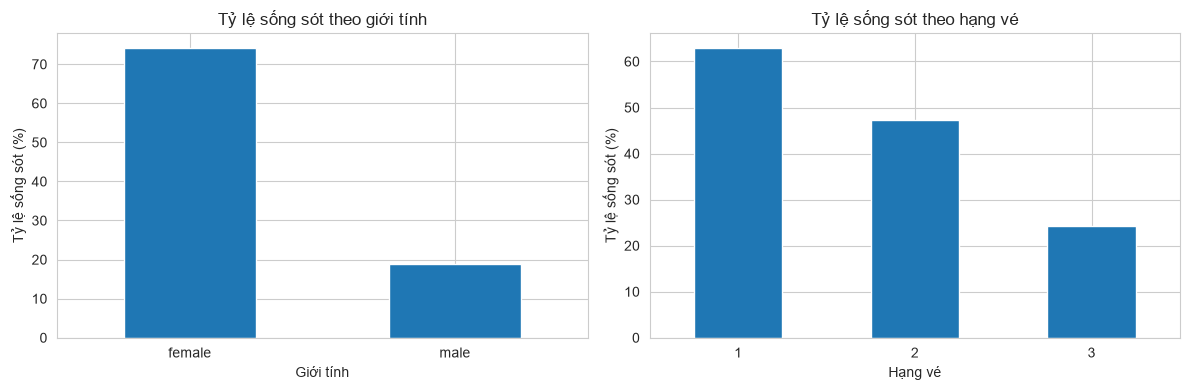

In [39]:
if sex_difference > class_difference:
    print("\n=> Giới tính có mức chênh lệch tỷ lệ sống sót lớn hơn hạng vé.")
else:
    print("\n=> Hạng vé có mức chênh lệch tỷ lệ sống sót lớn hơn giới tính.")

print()
print("Giới tính có mức chênh lệc tỷ lệ sống sót lớn hơn hạng vé => giới tính có mối liên hệ mạnh hơn với sống sót so với hạng vé")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
(survival_by_sex * 100).plot(kind='bar',ax=axes[0])
axes[0].set_title('Tỷ lệ sống sót theo giới tính')
axes[0].set_ylabel('Tỷ lệ sống sót (%)')
axes[0].set_xlabel('Giới tính')
axes[0].tick_params(axis='x', rotation=0)

(survival_by_class * 100).plot(kind='bar',ax=axes[1])
axes[1].set_title('Tỷ lệ sống sót theo hạng vé')
axes[1].set_ylabel('Tỷ lệ sống sót (%)')
axes[1].set_xlabel('Hạng vé')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## Câu hỏi 3: Vé đắt hơn có thực sự sống sót cao hơn không?

In [41]:
# TODO
df['fare_group'] = pd.qcut(df['fare'],q=4,labels=['Q1 - Rẻ nhất', 'Q2', 'Q3', 'Q4 - Đắt nhất'])

survival_by_fare = (df.groupby('fare_group', observed=True)['survived'].mean().sort_index())

print((survival_by_fare * 100).round(2))
print()
print("Những hành khách mua vé đắt hơn có xu hướng sống sót cao hơn.")

fare_group
Q1 - Rẻ nhất     19.73
Q2               30.36
Q3               45.50
Q4 - Đắt nhất    58.11
Name: survived, dtype: float64

Những hành khách mua vé đắt hơn có xu hướng sống sót cao hơn.


Tỷ lệ sống sót nhóm vé đắt nhất: 58.11%
Tỷ lệ sống sót nhóm vé rẻ nhất: 19.73%
nhóm vé đắt nhất có tỷ lệ sống cao hơn 38.38%


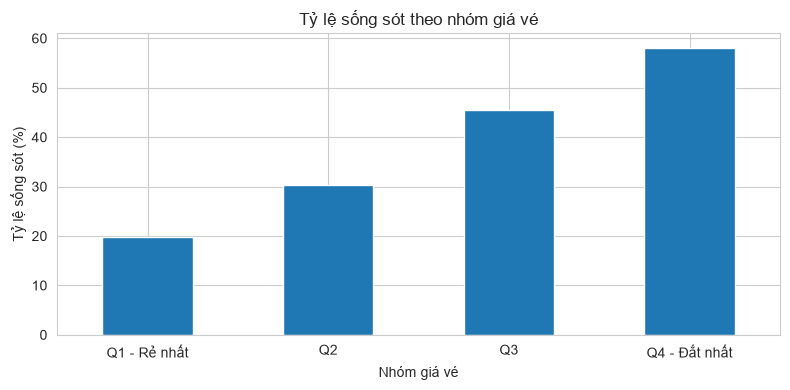

In [44]:
highest = survival_by_fare.iloc[-1] * 100
lowest = survival_by_fare.iloc[0] * 100

difference = highest - lowest

print(f"Tỷ lệ sống sót nhóm vé đắt nhất: {highest:.2f}%")
print(f"Tỷ lệ sống sót nhóm vé rẻ nhất: {lowest:.2f}%")
print(f"nhóm vé đắt nhất có tỷ lệ sống cao hơn {difference:.2f}%")

fig, ax = plt.subplots(figsize=(8, 4))
(survival_by_fare * 100).plot(kind='bar',ax=ax)

ax.set_title('Tỷ lệ sống sót theo nhóm giá vé')
ax.set_xlabel('Nhóm giá vé')
ax.set_ylabel('Tỷ lệ sống sót (%)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Câu hỏi 4: Gia đình đông người có ảnh hưởng đến khả năng sống sót không?

family_group
Đi một mình      30.35
Gia đình nhỏ     57.88
Gia đình đông    16.13
Name: survived, dtype: float64
dữ liệu cho thấy gia đình đông thì tỉ lệ sống sót thấp nhất


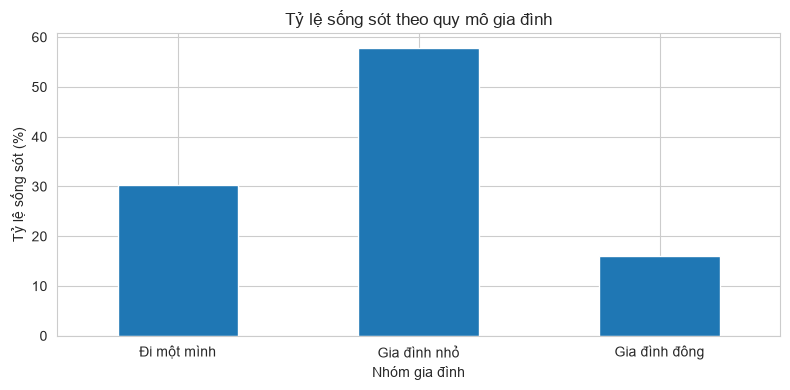

In [47]:
# TODO
df['family_group'] = pd.cut(df['family_size'],bins=[0, 1, 4, float('inf')],labels=['Đi một mình', 'Gia đình nhỏ', 'Gia đình đông'])

survival_by_family = (df.groupby('family_group', observed=True)['survived'].mean())
print((survival_by_family * 100).round(2))

print("dữ liệu cho thấy gia đình đông thì tỉ lệ sống sót thấp nhất")

fig, ax = plt.subplots(figsize=(8, 4))

(survival_by_family * 100).plot(kind='bar',ax=ax)

ax.set_title('Tỷ lệ sống sót theo quy mô gia đình')
ax.set_xlabel('Nhóm gia đình')
ax.set_ylabel('Tỷ lệ sống sót (%)')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Câu hỏi 5: Cảng lên tàu (embark_town) nào có tỷ lệ sống sót cao nhất?

embark_town
Cherbourg      55.36
Queenstown     38.96
Southampton    33.70
Name: survived, dtype: float64
=> Cảng tàu có tỷ lệ sống sót cao nhất là: Cherbourg


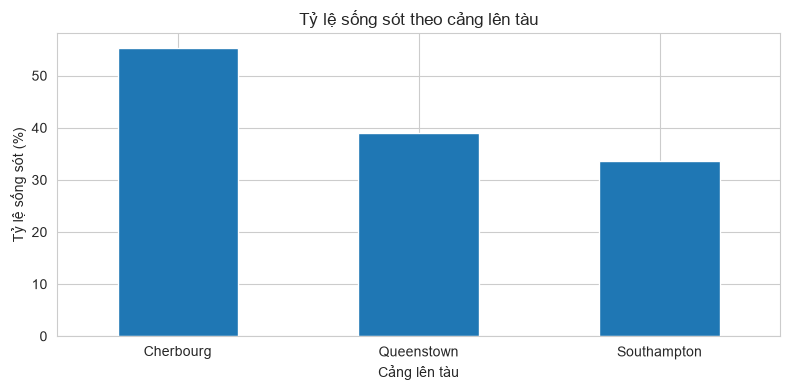

In [50]:
# TODO
survival_by_town = (df.groupby('embark_town')['survived'].mean().sort_values(ascending=False))

print((survival_by_town * 100).round(2))

print("=> Cảng tàu có tỷ lệ sống sót cao nhất là: Cherbourg")

fig, ax = plt.subplots(figsize=(8, 4))
(survival_by_town * 100).plot(kind='bar',ax=ax)

ax.set_title('Tỷ lệ sống sót theo cảng lên tàu')
ax.set_xlabel('Cảng lên tàu')
ax.set_ylabel('Tỷ lệ sống sót (%)')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể về dữ liệu Titanic.

insight: Nhìn chung thì dữ liệu của Titanic không có giá trị vô lý ở các biến, tuy vậy vẫn có một số biến như age và embark_town,..có dữ liệu thiếu nên cần lưu ý trong việc phân tích. Biến fare có độ lệch phải khá rõ dẫn đến có thể xuất hiện giá trị cực đoan cao cho thấy giá vé giữa các hành khách có sự chênh lệnh lớn. Theo kết quả phân tích thì cả hạng vé và giới tính đều có mối liên hệ với khả năng sống sót, giới tính có mức chênh lệch tỷ lệ sống sót cao hơn hạng vé. Những hành khách mua vé đắt hơn thường có xu hướng sống sót cao hơn, đồng thời tỷ lệ sống sót của người đi một mình hoặc gia đình nhỏ cũng cao hơn hành khách có gia đình đông. Ngoài ra, cảng Cherbourg được cho thấy là có tỷ lệ sống sót cao nhất dựa trên kết quả phân tích, điều này chứng tỏ rằng cảng lên tàu cũng có sụ khác biệt về tỷ lệ sống sót giữa các nhóm hành khách với nhau.